Day_12_Task Sheet
How a Model Learns: Backpropagation & Gradient Descent in Depth

Part A — backpropagation and the update rule

# TASK 01
# A backward pass by hand

In [ ]:
import numpy as np

x = 3.0
w = 1.0
target = 12.0
lr = 0.05

# -----------------------------
# Forward pass
# -----------------------------
a = w * x
loss = (a - target) ** 2

print("FORWARD PASS")
print("a    :", a)
print("loss :", loss)

# -----------------------------
# Backward pass
# -----------------------------
dloss_da = 2 * (a - target)
da_dw = x
dloss_dw = dloss_da * da_dw

print("\nBACKWARD PASS")
print("dloss/da :", dloss_da)
print("da/dw    :", da_dw)
print("dloss/dw :", dloss_dw)

# -----------------------------
# Gradient descent update
# -----------------------------
w_new = w - lr * dloss_dw

# Calculate new loss
a_new = w_new * x
loss_new = (a_new - target) ** 2

print("\nUPDATE")
print("old w   :", w)
print("gradient:", dloss_dw)
print("new w   :", w_new)

print("\nAFTER UPDATE")
print("new a    :", a_new)
print("new loss :", loss_new)

print("\nLOSS CHANGE")
print("Before:", loss)
print("After :", loss_new)
print("Loss decreased:", loss_new < loss)

FORWARD PASS
a    : 3.0
loss : 81.0

BACKWARD PASS
dloss/da : -18.0
da/dw    : 3.0
dloss/dw : -54.0

UPDATE
old w   : 1.0
gradient: -54.0
new w   : 3.7

AFTER UPDATE
new a    : 11.100000000000001
new loss : 0.8099999999999974

LOSS CHANGE
Before: 81.0
After : 0.8099999999999974
Loss decreased: True


# TASK 02
# Gradient descent from scratch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# Reusable Gradient Descent Optimiser
# ==========================================

def gradient_descent(grad_fn, start, lr, steps):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad_fn(x)
        history.append(x)

    return history


# ==========================================
# Function 1
# f(x) = (x - 5)^2
# ==========================================

def f(x):
    return (x - 5) ** 2


def grad_f(x):
    return 2 * (x - 5)


# ==========================================
# Run Gradient Descent
# ==========================================

start = 0.0
lr = 0.1
steps = 50

history = gradient_descent(
    grad_fn=grad_f,
    start=start,
    lr=lr,
    steps=steps
)


# ==========================================
# Results
# ==========================================

print("Gradient Descent Results")
print("-" * 30)

print(f"Starting position : {history[0]:.6f}")
print(f"Final position    : {history[-1]:.6f}")
print(f"Known minimum     : 5.000000")
print(f"Final function    : {f(history[-1]):.10f}")


# ==========================================
# First Six Positions
# ==========================================

print("\nFirst six positions")
print("-" * 30)

for i, x in enumerate(history[:6]):
    print(f"Step {i}: x = {x:.6f}")


Gradient Descent Results
------------------------------
Starting position : 0.000000
Final position    : 4.999929
Known minimum     : 5.000000
Final function    : 0.0000000051

First six positions
------------------------------
Step 0: x = 0.000000
Step 1: x = 1.000000
Step 2: x = 1.800000
Step 3: x = 2.440000
Step 4: x = 2.952000
Step 5: x = 3.361600


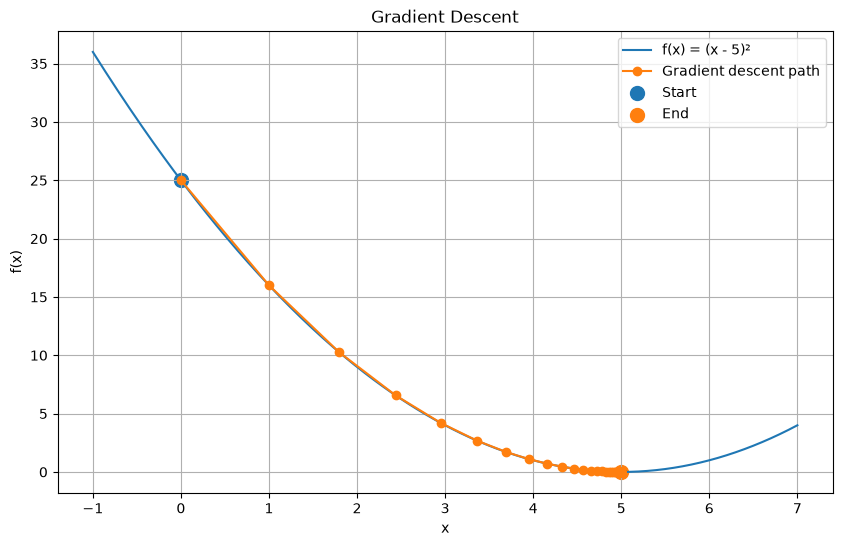

In [3]:
# ==========================================
# Plot Function + Descent Path
# ==========================================

x_values = np.linspace(-1, 7, 400)
y_values = f(x_values)

history_array = np.array(history)
path_y = f(history_array)

plt.figure(figsize=(10, 6))

# Function curve
plt.plot(
    x_values,
    y_values,
    label="f(x) = (x - 5)²"
)

# Gradient descent path
plt.plot(
    history_array,
    path_y,
    "o-",
    label="Gradient descent path"
)

# Start
plt.scatter(
    history_array[0],
    path_y[0],
    s=100,
    label="Start"
)

# End
plt.scatter(
    history_array[-1],
    path_y[-1],
    s=100,
    label="End"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

# Part B — learning rates and the landscape

# TASK 03 Sweep the learning rate until it breaks

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Reusable Gradient Descent
# ==========================================

def gradient_descent(grad_fn, start, lr, steps):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad_fn(x)
        history.append(x)

    return history


# ==========================================
# Function: f(x) = (x - 5)^2
# Gradient: 2(x - 5)
# ==========================================

def f(x):
    return (x - 5) ** 2


def grad(x):
    return 2 * (x - 5)


# ==========================================
# Learning Rate Sweep
# ==========================================

learning_rates = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.05]

print("LEARNING RATE SWEEP")
print("-" * 50)

for lr in learning_rates:
    path = gradient_descent(grad, 0.0, lr, 60)

    print(f"lr = {lr:<5} -> ended at x = {path[-1]:.6f}")


# ==========================================
# Print First Steps for Diverging Case
# ==========================================

print("\nDIVERGING RUN: lr = 1.05")
print("-" * 40)

path = gradient_descent(grad, 0.0, 1.05, 10)

for step, x in enumerate(path):
    print(f"Step {step:2d}: x = {x:.6f}")

LEARNING RATE SWEEP
--------------------------------------------------
lr = 0.001 -> ended at x = 0.565931
lr = 0.01  -> ended at x = 3.512234
lr = 0.1   -> ended at x = 4.999992
lr = 0.5   -> ended at x = 5.000000
lr = 0.9   -> ended at x = 4.999992
lr = 1.0   -> ended at x = 0.000000
lr = 1.05  -> ended at x = -1517.408198

DIVERGING RUN: lr = 1.05
----------------------------------------
Step  0: x = 0.000000
Step  1: x = 10.500000
Step  2: x = -1.050000
Step  3: x = 11.655000
Step  4: x = -2.320500
Step  5: x = 13.052550
Step  6: x = -3.857805
Step  7: x = 14.743586
Step  8: x = -5.717944
Step  9: x = 16.789738
Step 10: x = -7.968712


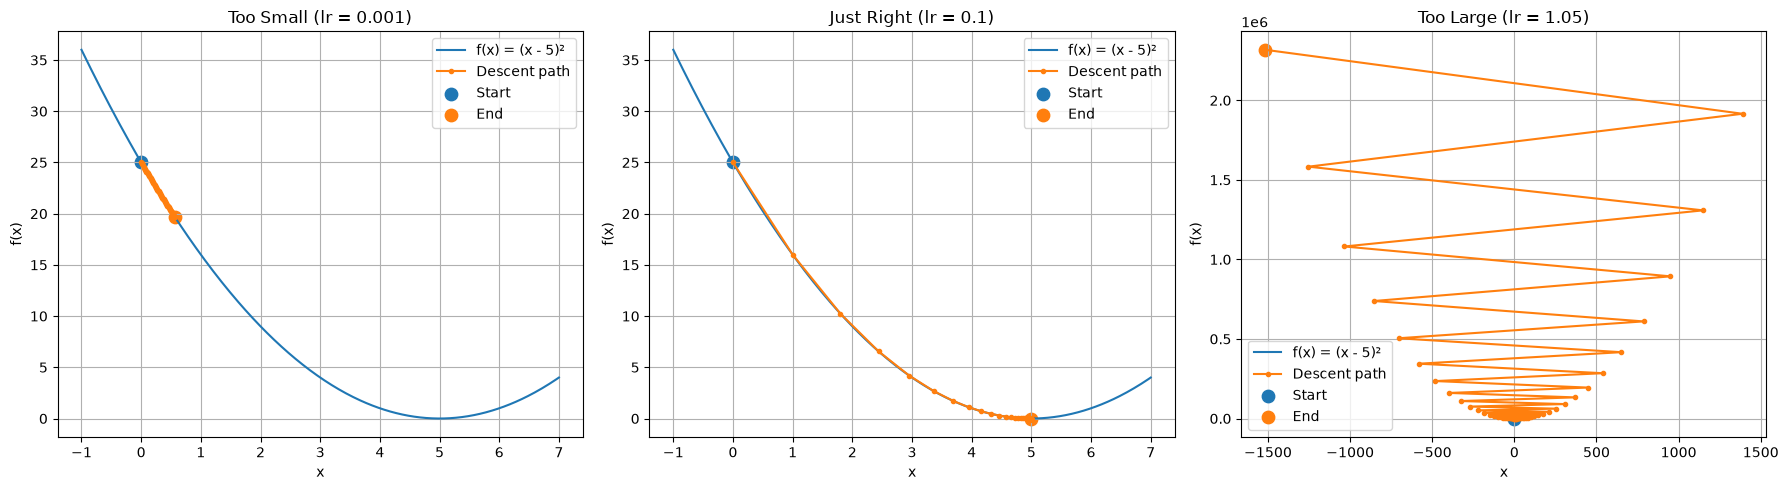


DIVERGENCE THRESHOLD
----------------------------------------
For f(x) = (x - 5)^2:
0 < lr < 1  -> converges
lr = 1      -> oscillates
lr > 1      -> diverges

Threshold learning rate = 1.0

EXPLANATION
----------------------------------------
A too-large learning rate overshoots the minimum and jumps to the opposite side.
Each overshoot becomes larger, so the distance from the minimum grows and the optimisation diverges.


In [5]:
# ==========================================
# Three Descent Path Plots
# ==========================================

learning_rates = [0.001, 0.1, 1.05]
titles = [
    "Too Small (lr = 0.001)",
    "Just Right (lr = 0.1)",
    "Too Large (lr = 1.05)"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, lr, title in zip(axes, learning_rates, titles):

    path = np.array(
        gradient_descent(grad, 0.0, lr, 60)
    )

    # Use a wider range for the diverging case
    if lr == 1.05:
        x_values = np.linspace(-100, 100, 500)
    else:
        x_values = np.linspace(-1, 7, 400)

    # Function curve
    ax.plot(
        x_values,
        f(x_values),
        label="f(x) = (x - 5)²"
    )

    # Gradient descent path
    ax.plot(
        path,
        f(path),
        "o-",
        markersize=3,
        label="Descent path"
    )

    # Start and end
    ax.scatter(
        path[0],
        f(path[0]),
        s=80,
        label="Start"
    )

    ax.scatter(
        path[-1],
        f(path[-1]),
        s=80,
        label="End"
    )

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


# ==========================================
# Divergence Threshold
# ==========================================

print("\nDIVERGENCE THRESHOLD")
print("-" * 40)

print("For f(x) = (x - 5)^2:")
print("0 < lr < 1  -> converges")
print("lr = 1      -> oscillates")
print("lr > 1      -> diverges")

print("\nThreshold learning rate = 1.0")


# ==========================================
# Explanation
# ==========================================

print("\nEXPLANATION")
print("-" * 40)

print(
    "A too-large learning rate overshoots the minimum "
    "and jumps to the opposite side."
)

print(
    "Each overshoot becomes larger, so the distance from "
    "the minimum grows and the optimisation diverges."
)

# TASK 04 Local minima and convexity

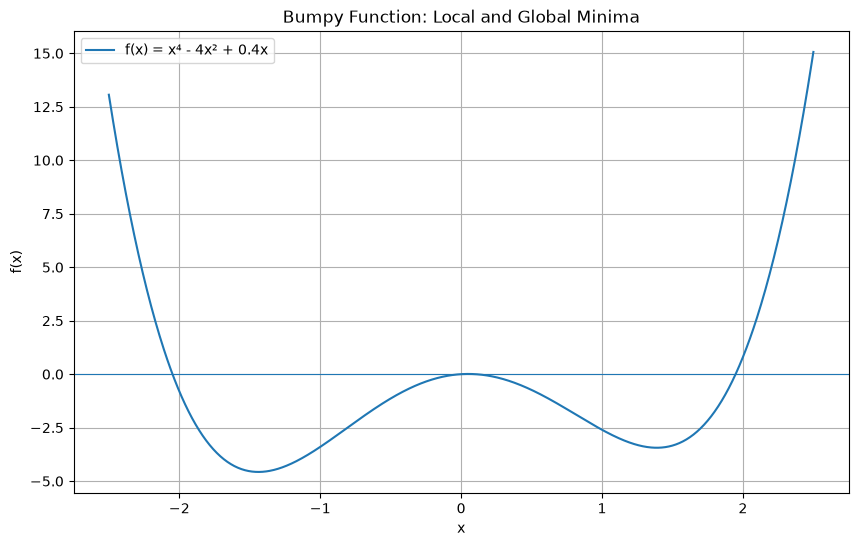

In [6]:
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# Reusable Gradient Descent
# ==========================================

def gradient_descent(grad_fn, start, lr, steps):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad_fn(x)
        history.append(x)

    return history


# ==========================================
# Bumpy Function
# f(x) = x^4 - 4x^2 + 0.4x
# ==========================================

def f(x):
    return x**4 - 4*x**2 + 0.4*x


def grad(x):
    return 4*x**3 - 8*x + 0.4


# ==========================================
# Plot the Bumpy Function
# ==========================================

x_values = np.linspace(-2.5, 2.5, 1000)
y_values = f(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label="f(x) = x⁴ - 4x² + 0.4x")

plt.axhline(0, linewidth=0.8)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Bumpy Function: Local and Global Minima")
plt.grid(True)
plt.legend()
plt.show()

GRADIENT DESCENT RESULTS
--------------------------------------------------
Start  -2.0 -> End -1.438580 | f(x) = -4.570600
Start  -0.5 -> End -1.438580 | f(x) = -4.570600
Start   0.5 -> End 1.388517 | f(x) = -3.439406
Start   2.2 -> End 1.388517 | f(x) = -3.439406


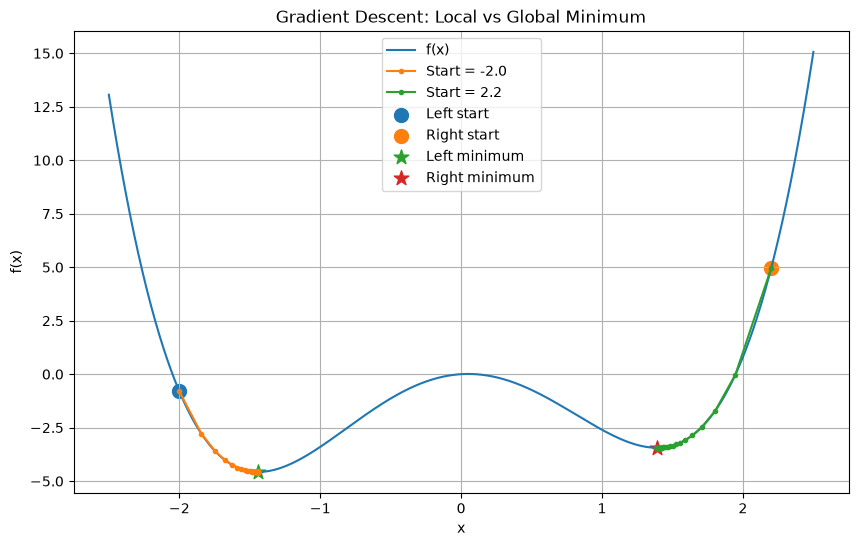

In [7]:
# ==========================================
# Gradient Descent from Several Starts
# ==========================================

starts = [-2.0, -0.5, 0.5, 2.2]
lr = 0.01
steps = 200

print("GRADIENT DESCENT RESULTS")
print("-" * 50)

paths = {}

for start in starts:
    path = gradient_descent(grad, start, lr, steps)
    paths[start] = np.array(path)

    print(
        f"Start {start:>5.1f} -> "
        f"End {path[-1]:.6f} | "
        f"f(x) = {f(path[-1]):.6f}"
    )


# ==========================================
# Plot Two Descent Paths
# ==========================================

plt.figure(figsize=(10, 6))

# Function
plt.plot(
    x_values,
    y_values,
    label="f(x)"
)

# Path from left side
path_left = paths[-2.0]

plt.plot(
    path_left,
    f(path_left),
    "o-",
    markersize=3,
    label="Start = -2.0"
)

# Path from right side
path_right = paths[2.2]

plt.plot(
    path_right,
    f(path_right),
    "o-",
    markersize=3,
    label="Start = 2.2"
)

# Starting points
plt.scatter(
    path_left[0],
    f(path_left[0]),
    s=100,
    label="Left start"
)

plt.scatter(
    path_right[0],
    f(path_right[0]),
    s=100,
    label="Right start"
)

# Ending points
plt.scatter(
    path_left[-1],
    f(path_left[-1]),
    s=120,
    marker="*",
    label="Left minimum"
)

plt.scatter(
    path_right[-1],
    f(path_right[-1]),
    s=120,
    marker="*",
    label="Right minimum"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent: Local vs Global Minimum")
plt.grid(True)
plt.legend()
plt.show()



CONVEX FUNCTION RESULTS
--------------------------------------------------
Start  -5.0 -> End 2.000000 | f(x) = 0.00000000
Start  -1.0 -> End 2.000000 | f(x) = 0.00000000
Start   0.0 -> End 2.000000 | f(x) = 0.00000000
Start   5.0 -> End 2.000000 | f(x) = 0.00000000
Start  10.0 -> End 2.000000 | f(x) = 0.00000000


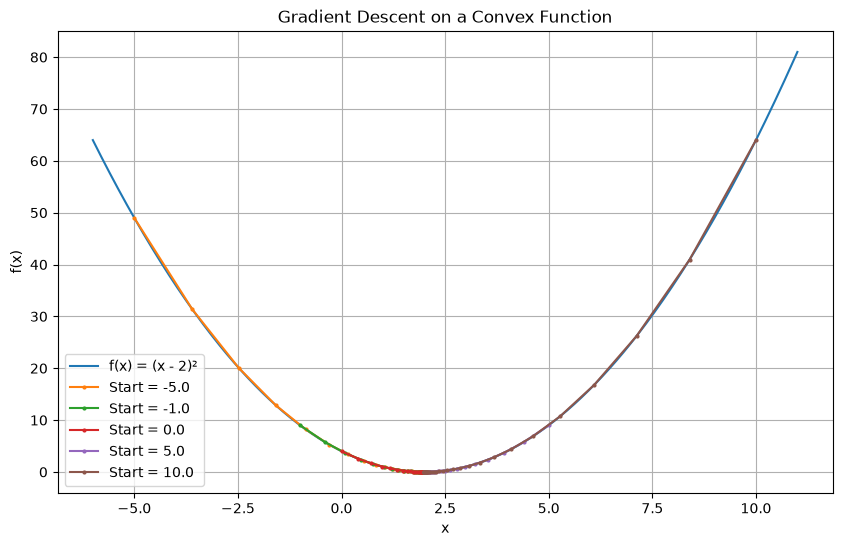


EXPLANATION
--------------------------------------------------
For the bumpy function, different starting points can fall into different valleys, so gradient descent can become trapped in a local minimum.
For the convex function, there is only one global minimum, so different starting points all descend toward the same minimum.


In [8]:
# ==========================================
# Convex Function
# f(x) = (x - 2)^2
# ==========================================

def convex_f(x):
    return (x - 2)**2


def convex_grad(x):
    return 2 * (x - 2)


convex_starts = [-5.0, -1.0, 0.0, 5.0, 10.0]

print("\nCONVEX FUNCTION RESULTS")
print("-" * 50)

convex_paths = {}

for start in convex_starts:
    path = gradient_descent(
        convex_grad,
        start,
        lr=0.1,
        steps=100
    )

    convex_paths[start] = np.array(path)

    print(
        f"Start {start:>5.1f} -> "
        f"End {path[-1]:.6f} | "
        f"f(x) = {convex_f(path[-1]):.8f}"
    )


# ==========================================
# Plot Convex Function Paths
# ==========================================

x_convex = np.linspace(-6, 11, 500)

plt.figure(figsize=(10, 6))

plt.plot(
    x_convex,
    convex_f(x_convex),
    label="f(x) = (x - 2)²"
)

for start, path in convex_paths.items():
    plt.plot(
        path,
        convex_f(path),
        "o-",
        markersize=2,
        label=f"Start = {start}"
    )

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent on a Convex Function")
plt.grid(True)
plt.legend()
plt.show()


# ==========================================
# Final Explanation
# ==========================================

print("\nEXPLANATION")
print("-" * 50)

print(
    "For the bumpy function, different starting points can fall "
    "into different valleys, so gradient descent can become trapped "
    "in a local minimum."
)

print(
    "For the convex function, there is only one global minimum, "
    "so different starting points all descend toward the same minimum."
)

# Part C — 2D descent and escaping traps

# TASK 05 Gradient descent in 2D on a contour plot

In [9]:
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# 2D Gradient Descent
# ==========================================

def gradient_descent_2d(grad_fn, start, lr, steps):
    p = np.array(start, dtype=float)
    history = [p.copy()]

    for _ in range(steps):
        p = p - lr * grad_fn(p)
        history.append(p.copy())

    return np.array(history)


# ==========================================
# Function
# f(x, y) = x² + 3y²
# Gradient = (2x, 6y)
# ==========================================

def f(x, y):
    return x**2 + 3*y**2


def grad(p):
    return np.array([
        2 * p[0],
        6 * p[1]
    ])


# ==========================================
# Run from [4, 4]
# ==========================================

start = [4.0, 4.0]
lr = 0.1
steps = 40

path = gradient_descent_2d(
    grad,
    start,
    lr,
    steps
)

print("2D Gradient Descent")
print("-" * 40)
print("Starting point:", path[0])
print("Ending point  :", path[-1])
print("Minimum       : [0, 0]")


# ==========================================
# Print first few positions
# ==========================================

print("\nFirst 6 positions")
print("-" * 40)

for i, p in enumerate(path[:6]):
    print(f"Step {i}: [{p[0]:.6f}, {p[1]:.6f}]")


2D Gradient Descent
----------------------------------------
Starting point: [4. 4.]
Ending point  : [5.31691198e-04 4.83570328e-16]
Minimum       : [0, 0]

First 6 positions
----------------------------------------
Step 0: [4.000000, 4.000000]
Step 1: [3.200000, 1.600000]
Step 2: [2.560000, 0.640000]
Step 3: [2.048000, 0.256000]
Step 4: [1.638400, 0.102400]
Step 5: [1.310720, 0.040960]


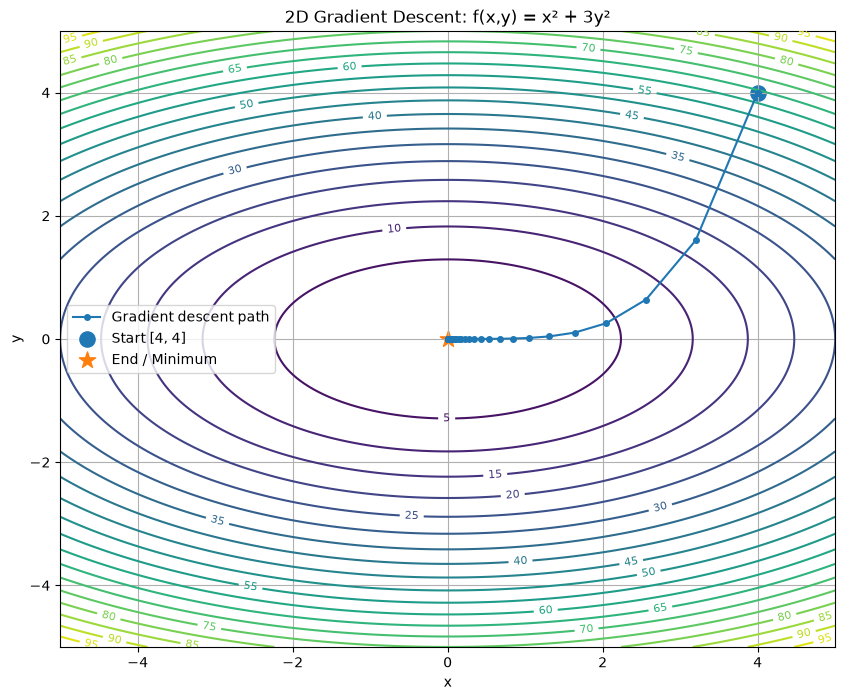

In [10]:
# ==========================================
# Create Contour Plot
# ==========================================

x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)

X, Y = np.meshgrid(x, y)

Z = f(X, Y)

plt.figure(figsize=(10, 8))

# Contour plot
contours = plt.contour(
    X,
    Y,
    Z,
    levels=20
)

plt.clabel(
    contours,
    inline=True,
    fontsize=8
)

# Descent path
plt.plot(
    path[:, 0],
    path[:, 1],
    "o-",
    markersize=4,
    label="Gradient descent path"
)

# Starting point
plt.scatter(
    path[0, 0],
    path[0, 1],
    s=120,
    label="Start [4, 4]"
)

# Final point
plt.scatter(
    path[-1, 0],
    path[-1, 1],
    s=150,
    marker="*",
    label="End / Minimum"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Gradient Descent: f(x,y) = x² + 3y²")
plt.legend()
plt.grid(True)

plt.show()




YOUR EXPERIMENT
----------------------------------------
Starting point: [-4.  3.]
Learning rate : 0.05
Ending point  : [-7.18804120e-03  1.52406558e-09]


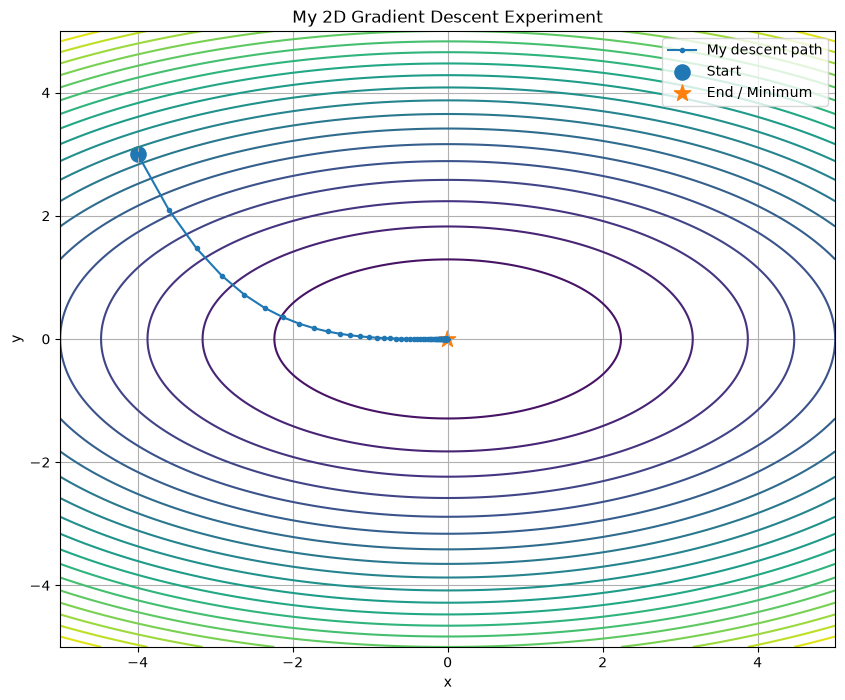


EXPLANATION
----------------------------------------
The bowl is steeper in the y direction because its gradient component is 6y, while the x component is only 2x.
Therefore, gradient descent moves faster in the y direction than in the x direction, producing a curved path toward [0, 0].


In [11]:
# ==========================================
# Try Your Own Starting Point + Learning Rate
# ==========================================

my_start = [-4.0, 3.0]
my_lr = 0.05
my_steps = 60

my_path = gradient_descent_2d(
    grad,
    my_start,
    my_lr,
    my_steps
)

print("\nYOUR EXPERIMENT")
print("-" * 40)
print("Starting point:", my_path[0])
print("Learning rate :", my_lr)
print("Ending point  :", my_path[-1])


# Plot your experiment
plt.figure(figsize=(10, 8))

plt.contour(
    X,
    Y,
    Z,
    levels=20
)

plt.plot(
    my_path[:, 0],
    my_path[:, 1],
    "o-",
    markersize=3,
    label="My descent path"
)

plt.scatter(
    my_path[0, 0],
    my_path[0, 1],
    s=120,
    label="Start"
)

plt.scatter(
    my_path[-1, 0],
    my_path[-1, 1],
    s=150,
    marker="*",
    label="End / Minimum"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("My 2D Gradient Descent Experiment")
plt.legend()
plt.grid(True)

plt.show()


# ==========================================
# Explanation
# ==========================================

print("\nEXPLANATION")
print("-" * 40)

print(
    "The bowl is steeper in the y direction because its gradient "
    "component is 6y, while the x component is only 2x."
)

print(
    "Therefore, gradient descent moves faster in the y direction "
    "than in the x direction, producing a curved path toward [0, 0]."
)

# TASK 06 Momentum: escape a shallow minimum

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Two-minima function from Task 04
def f(x):
    return x**4 - 4*x**2 + 0.4*x

# Gradient of f(x)
def grad(x):
    return 4*x**3 - 8*x + 0.4


# ------------------------------------------------------------
# Plain Gradient Descent
# ------------------------------------------------------------
def gradient_descent(start, lr=0.01, steps=800):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad(x)
        history.append(x)

    return np.array(history)


# ------------------------------------------------------------
# Momentum Gradient Descent
# v = beta*v - lr*grad(x)
# x = x + v
# ------------------------------------------------------------
def momentum_gd(start, lr=0.01, beta=0.9, steps=800):
    x = start
    v = 0.0
    history = [x]

    for _ in range(steps):
        v = beta * v - lr * grad(x)
        x = x + v
        history.append(x)

    return np.array(history)


# ------------------------------------------------------------
# Starting point on the shallow side
# ------------------------------------------------------------
start = 2.2
lr = 0.01
beta = 0.9
steps = 800

# Run both methods
plain_path = gradient_descent(start, lr, steps)
momentum_path = momentum_gd(start, lr, beta, steps)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------
print("Starting point:", start)
print()
print("Plain Gradient Descent:")
print("  Final x    =", round(plain_path[-1], 6))
print("  Final f(x) =", round(f(plain_path[-1]), 6))
print()
print("Momentum Gradient Descent:")
print("  Final x    =", round(momentum_path[-1], 6))
print("  Final f(x) =", round(f(momentum_path[-1]), 6))

Starting point: 2.2

Plain Gradient Descent:
  Final x    = 1.388517
  Final f(x) = -3.439406

Momentum Gradient Descent:
  Final x    = -1.43858
  Final f(x) = -4.5706


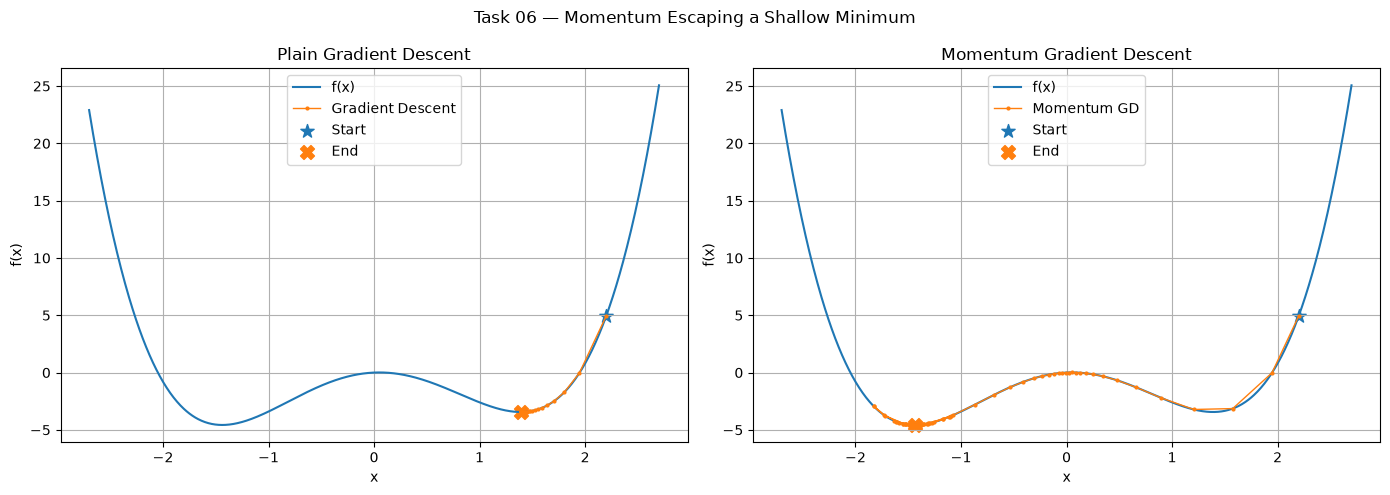


Explanation:
In physical terms, plain gradient descent behaves like a ball that loses its speed near the shallow minimum, so it settles there.
Momentum gives the ball inertia, allowing it to carry enough velocity through the shallow valley and over the hill into the deeper global minimum.


In [15]:
# ------------------------------------------------------------
# Function curve
# ------------------------------------------------------------
x_values = np.linspace(-2.7, 2.7, 1000)
y_values = f(x_values)

# ------------------------------------------------------------
# Plot both paths side by side
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===== Plain Gradient Descent =====
axes[0].plot(x_values, y_values, label="f(x)")
axes[0].plot(
    plain_path,
    f(plain_path),
    "o-",
    markersize=2,
    linewidth=1,
    label="Gradient Descent"
)

axes[0].scatter(
    start,
    f(start),
    s=100,
    marker="*",
    label="Start"
)

axes[0].scatter(
    plain_path[-1],
    f(plain_path[-1]),
    s=100,
    marker="X",
    label="End"
)

axes[0].set_title("Plain Gradient Descent")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].grid(True)
axes[0].legend()


# ===== Momentum Gradient Descent =====
axes[1].plot(x_values, y_values, label="f(x)")
axes[1].plot(
    momentum_path,
    f(momentum_path),
    "o-",
    markersize=2,
    linewidth=1,
    label="Momentum GD"
)

axes[1].scatter(
    start,
    f(start),
    s=100,
    marker="*",
    label="Start"
)

axes[1].scatter(
    momentum_path[-1],
    f(momentum_path[-1]),
    s=100,
    marker="X",
    label="End"
)

axes[1].set_title("Momentum Gradient Descent")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")
axes[1].grid(True)
axes[1].legend()

plt.suptitle("Task 06 — Momentum Escaping a Shallow Minimum")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Two-sentence explanation
# ------------------------------------------------------------
print("\nExplanation:")
print(
    "In physical terms, plain gradient descent behaves like a ball that "
    "loses its speed near the shallow minimum, so it settles there."
)
print(
    "Momentum gives the ball inertia, allowing it to carry enough velocity "
    "through the shallow valley and over the hill into the deeper global minimum."
)